In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Comparing different control efforts related to an adaptive coupling constant, against that of a fixed constant

Case 1 - adapting based on the current phase difference $\varphi = (\theta_j - \theta_i)$

[inf, np.float64(19.820890765131292), np.float64(18.67040203561709), np.float64(16.5264090628075), np.float64(14.35557025044661), np.float64(12.463688251837665), np.float64(10.871056212611188), np.float64(9.514246300419499), np.float64(8.315089777235892), np.float64(7.1654582533698346), np.float64(7.229937097102807), np.float64(8.329006031926163), np.float64(9.512025231090327), np.float64(10.949242210430597), np.float64(12.502951746345158), np.float64(14.323823620590787), np.float64(16.540360190718594), np.float64(18.82484979349077), np.float64(19.80168194159407), inf]


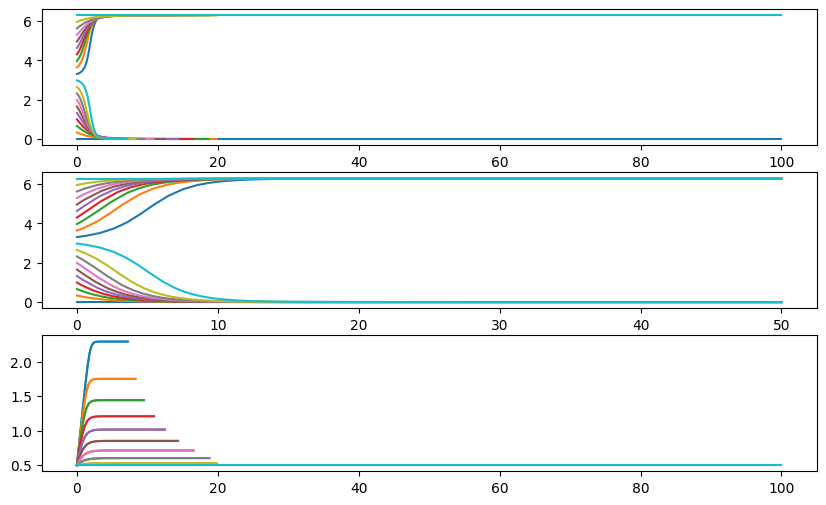

In [2]:
def rhs_updates(t,y,omega,eta):
    
    delta = y[0]
    kappa = y[1]


    dphi_dt = omega - kappa*np.sin(delta)
    dkappa_dt = eta*(1 - np.cos(delta))

    return [dphi_dt,dkappa_dt]

def phi_dot(t,y,omega):

    phi = y[0]
    K = y[1]

    return [omega - K * np.sin(phi),0]


def steady(t,y,omega,eta):
    delta = (y[0] % (2*np.pi))
    threshold = 1e-5
    return min(abs(delta),abs(delta - 2*np.pi)) - threshold

steady.terminal = True
#steady.direction = -1

init_phi = np.linspace(0,2*np.pi,20)
init_K = 0.5

center = 4 * np.pi
spread = 0.5
w1 = np.random.uniform(center - spread, center + spread)
w2 = np.random.uniform(center - spread, center + spread)
omega = 0
critical = abs(omega)


eta = 0.5

fig,axs = plt.subplots(3,1,figsize=(10,6))

sync_times = []
for phi0 in init_phi:
    sol_adaptive = solve_ivp(rhs_updates,[0,100],[phi0,init_K],args=(omega,eta),rtol=1e-6,events=steady)
    axs[0].plot(sol_adaptive.t,sol_adaptive.y[0])
    axs[2].plot(sol_adaptive.t,sol_adaptive.y[1])

    if len(sol_adaptive.t_events[0]) > 0:
        sync_times.append(sol_adaptive.t_events[0][0])
    else:
        sync_times.append(np.inf)
print(sync_times)

for phi0 in init_phi:
    sol_fixed = solve_ivp(phi_dot,[0,50],[phi0,init_K],args=(omega,),rtol=1e-6)
    axs[1].plot(sol_fixed.t,sol_fixed.y[0])

#np trapz can solve these

#also consider time to sync, or required control effort against start positions

Adapting based on phase coherence $r(t)$, maybe avg phase.

Using the $N_{oscillators} \rightarrow \infty$ case

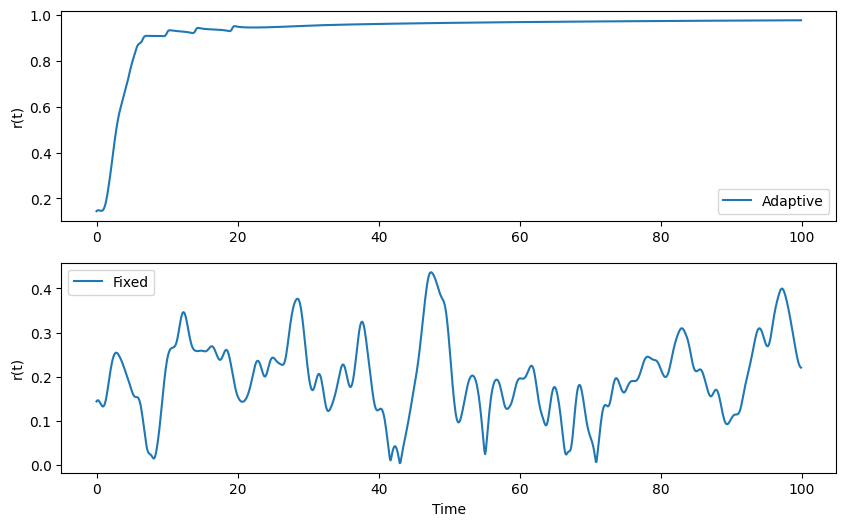

In [25]:
N = 100

omega = np.random.randn(N)
K = 1
theta = np.random.uniform(0,2*np.pi,N)

omega_init = omega.copy()
theta_init = theta.copy()

dt = 0.1
time = np.arange(0,100,dt)

r_history_adaptive = np.zeros(len(time))
sols = []

eta = 0.5

fig,axs = plt.subplots(2,1,figsize=(10,6))
K_adaptive = []


for idx,t in enumerate(time):
 
    z = np.mean(np.exp(1j*theta_init))
    r = np.abs(z)
    psi = np.angle(z)

    r_history_adaptive[idx] = r

    K += eta*(1 - r)*dt
    K_adaptive.append(K)

    theta_dot = omega_init + K*r*np.sin(psi - theta_init)
    sols.append(theta_dot)
    theta_init += theta_dot * dt

axs[0].plot(time,r_history_adaptive,label='Adaptive')
axs[0].set_ylabel('r(t)')
axs[0].legend()

r_history = np.zeros(len(time))

K = 1
omega_init = omega.copy()
theta_init = theta.copy()



for idx,t in enumerate(time):
 
    z = np.mean(np.exp(1j*theta_init))
    r = np.abs(z)
    psi = np.angle(z)

    r_history[idx] = r

    theta_dot = omega_init + K*r*np.sin(psi - theta_init)
    sols.append(theta_dot)
    theta_init += theta_dot * dt

axs[1].plot(time,r_history,label='Fixed')
axs[1].set_ylabel('r(t)')
axs[1].set_xlabel('Time')
axs[1].legend()

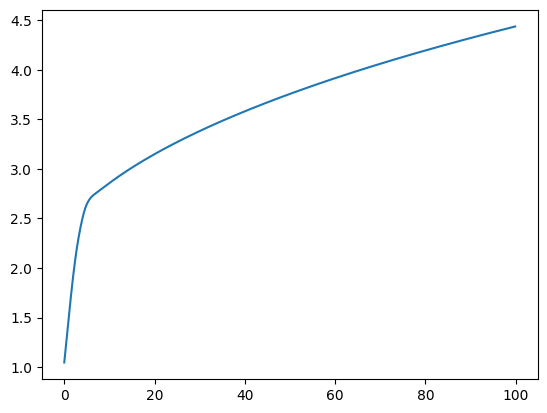

In [18]:
plt.plot(time,K_adaptive)